# Sine distortion analysis

In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

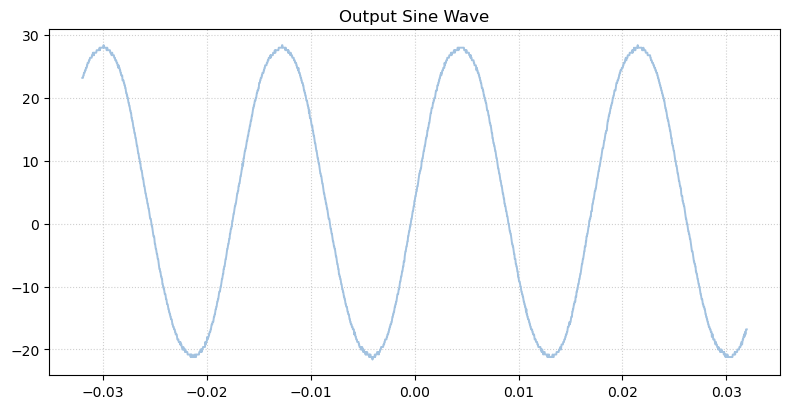

In [203]:
# df = pd.read_csv('sine_only_waveform_CH1.CSV', skiprows=15)
# df = pd.read_csv('sine_18V.CSV', skiprows=15)
df = pd.read_csv('sine_18V_new.CSV', skiprows=15)
# df = pd.read_csv('sine_18V_FFT.CSV', skiprows=15)
df.head()

plt.figure(figsize=(8,4))
# plt.scatter(df['TIME'], df['CH1'], color='#A2C2E0', s=5)
plt.plot(df['TIME'], df['CH1'], color='#A2C2E0', linewidth=1.4)
# plt.plot(df['FFT-FREQ'], df['FFT-AMPL'], color='#A2C2E0', linewidth=1.4)
# plt.xlabel('Time (s)', fontsize=11)
# plt.ylabel('Voltage (V)', fontsize=11)
# plt.xlabel('Frequency')
# plt.ylabel('count (not magnitude)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', labelsize=10)
plt.tight_layout()
# plt.xlim(-0.008, 0.008)
# plt.ylim(-4, 5)
plt.title('Output Sine Wave')
plt.show()

Δt = 3.200100e-05 s, fs = 31249.02 Hz
Fundamental frequency: 109.37 Hz


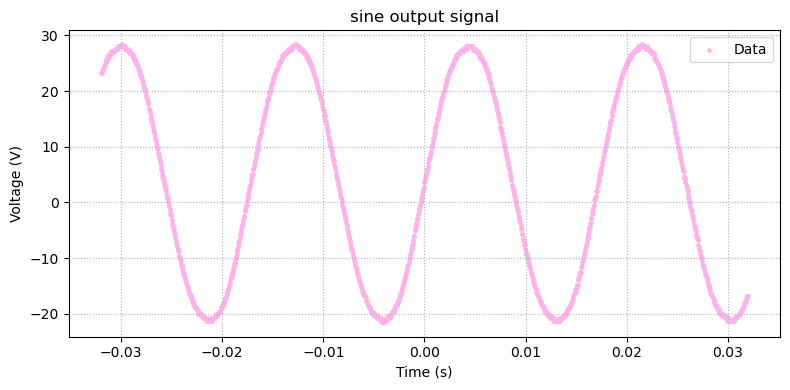

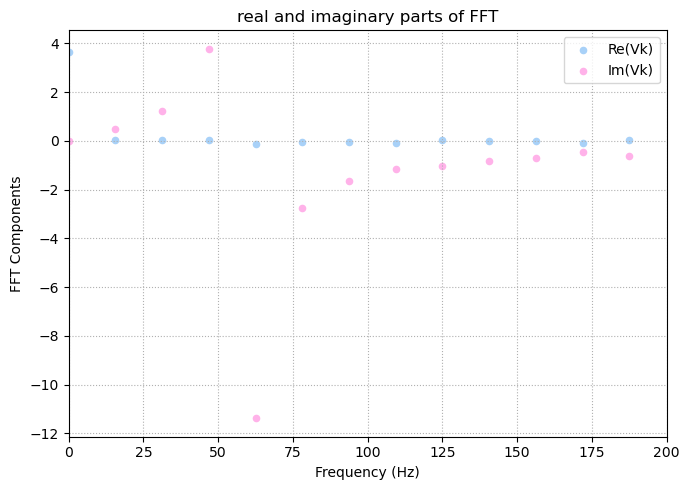

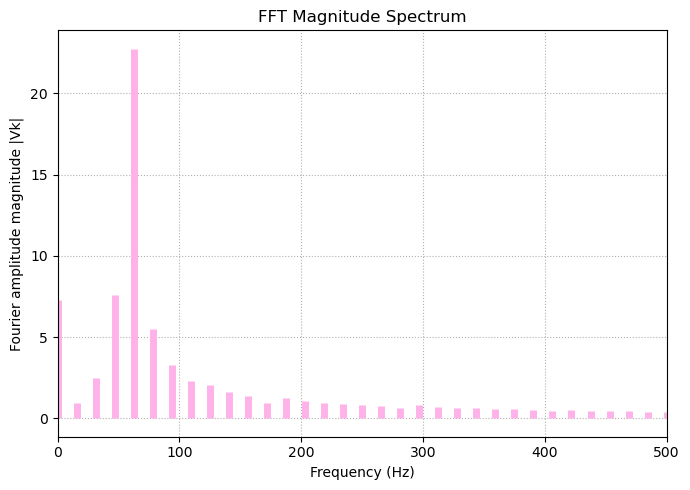

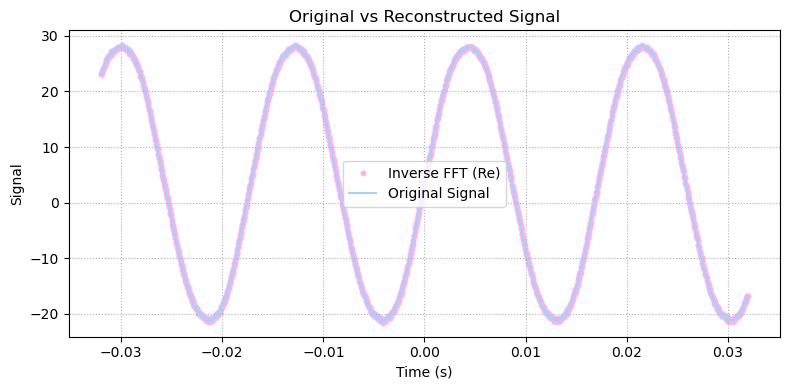

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft
from scipy.interpolate import interp1d

# read waveform
# df = pd.read_csv('sine_only_waveform_CH1.CSV', skiprows=15)
# df = pd.read_csv('sine_18V.CSV', skiprows=15)
# df = pd.read_csv('sine_18V_FFT.CSV', skiprows=15)
t = df['TIME'].values
v = df['CH1'].values

# sampling parameters
N = len(t)
dt = np.mean(np.diff(t))
fs = 1 / dt
T = N * dt
print(f"Δt = {dt:.6e} s, fs = {fs:.2f} Hz")

# FFT
Vk = fft(v) / N
frequencies = np.fft.fftfreq(N, d=dt)
fk = frequencies[:N // 2]
Vk_pos = Vk[:N // 2]
Vk_mag = 2 * np.abs(Vk_pos)  # single-sided spectrum

# Band to search for fundamental frequency
f_min, f_max = 100, 500  # adjust as needed
band_mask = (fk >= f_min) & (fk <= f_max)
fk_band = fk[band_mask]
Vk_band = Vk_mag[band_mask]
# Find index of fundamental peak in this band
peak_idx = np.argmax(Vk_band)
f1 = fk_band[peak_idx]
fundamental_idx = np.argmin(np.abs(fk - f1))
V1 = Vk_mag[fundamental_idx]
print(f"Fundamental frequency: {f1:.2f} Hz")

# inverse FFT
v_reconstructed = N * ifft(Vk)

# For smooth plot of input signal
tqc = np.linspace(t[0], t[-1], 10 * N)
interp_func = interp1d(t, v, kind='cubic')
v_tqc = interp_func(tqc)

# (1) measured sine output
plt.figure(figsize=(8, 4))
# plt.plot(tqc, v_tqc, label='Interpolated Input Signal', color="#A8D1F8")
plt.scatter(t, v, s=5, color="#FFB2E9", label='Data')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('sine output signal')
plt.legend()
plt.grid(True, linestyle=':')
# plt.xlim(-0.008, 0.008)
# plt.ylim(-4, 5)
plt.tight_layout()
plt.show()

# (2) real and im parts of FFT
plt.figure(figsize=(7, 5))
plt.scatter(fk, np.real(Vk_pos), s=20, c='#A8D1F8', label='Re(Vk)')
plt.scatter(fk, np.imag(Vk_pos), s=20, c='#FFB2E9', label='Im(Vk)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('FFT Components')
plt.title('real and imaginary parts of FFT')
plt.legend()
plt.grid(True, linestyle=':')
plt.xlim(0, fs / 2)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# (3) FFT magnitude spectrum
plt.figure(figsize=(7, 5))
# plt.scatter(fk, Vk_mag, s=20, color='#FFB2E9')
# plt.plot(fk, Vk_mag, color='#FFB2E9')
# plt.stem(fk, Vk_mag, use_line_collection=True)
plt.vlines(fk, 0, Vk_mag, colors='b', linestyles='-', lw=5, color='#FFB2E9')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Fourier amplitude magnitude |Vk|')
plt.title('FFT Magnitude Spectrum')
plt.grid(True, linestyle=':')
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

# (4) plot inverse FFT and original signal
plt.figure(figsize=(8, 4))
plt.scatter(t, v_reconstructed.real, s=10, label='Inverse FFT (Re)', color="#FFB2E9")
plt.plot(tqc, v_tqc, label='Original Signal', color='#A8D1F8')
plt.xlabel('Time (s)')
plt.ylabel('Signal')
plt.title('Original vs Reconstructed Signal')
plt.legend()
plt.grid(True, linestyle=':')
# plt.xlim(-0.008, 0.008)
# plt.ylim(-4, 4)
plt.tight_layout()
plt.show()


#### NOTE: use the FFT spectrum to get the 

### RMS sine fit

1. Define sine function model
$$
V(t)=A\sin(2\pi ft+\phi) + offset
$$

2. Estimate using initial parameters
- A (from peak values)
- f (from zero crossings or FFT)
- $\phi$ (0 to start)
- offset (mean of signal)

3. fit using `curve_fit`

4. calculate RMS value of fitted sine wave
$$
\text{RMS}=\frac{A}{\sqrt{2}}
$$

5. Plot original and fitted sine wave


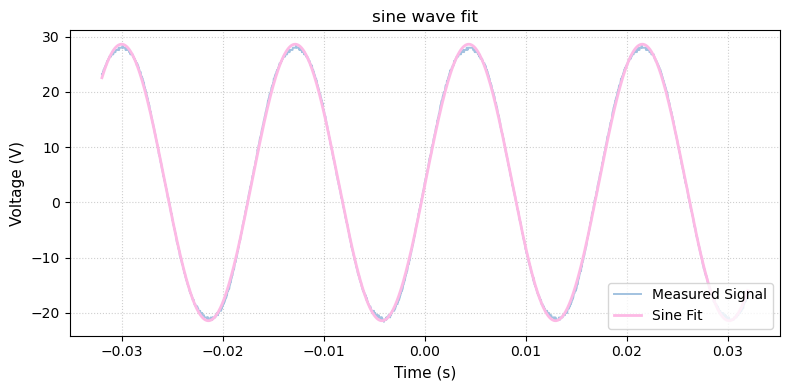

Amplitude (A): 25.0182 V
Frequency (f): 58.16 Hz
Phase (phi): -0.0136 rad
Offset: 3.6204 V
RMS Voltage: 17.6905 V


In [205]:
# (2) RMS sine fit

# define sine function
def sine(t, A, f, phi, offset):
    return A * np.sin(2 * np.pi * f * t + phi) + offset

# estimate initial parameters
A_guess = (np.max(v) - np.min(v)) / 2
offset_guess = np.mean(v)

# Estimate frequency using FFT
sample_spacing = np.mean(np.diff(t))
fs = 1 / sample_spacing  # Sampling rate
n = len(v)
frequencies = np.fft.fftfreq(n, d=sample_spacing)
fft_vals = np.abs(np.fft.fft(v))
peak_freq = abs(frequencies[np.argmax(fft_vals[:n // 2])])  # Use only positive freqs

# Initial guess: [Amplitude, Frequency, Phase, Offset]
initial_guess = [A_guess, peak_freq, 0, offset_guess]

# Curve fitting
params, _ = curve_fit(sine, t, v, p0=initial_guess)
A_fit, f_fit, phi_fit, offset_fit = params

# Calculate RMS from amplitude
rms_voltage = A_fit / np.sqrt(2)

# Generate fitted waveform for plotting
t_fit = np.linspace(t[0], t[-1], 1000)
v_fit = sine(t_fit, *params)

# Plot measured and fitted waveform
plt.figure(figsize=(8, 4))
plt.plot(t, v, label='Measured Signal', color='#A2C2E0', linewidth=1.4)
plt.plot(t_fit, v_fit, label='Sine Fit', color="#FDB9E5", linewidth=2)
plt.xlabel('Time (s)', fontsize=11)
plt.ylabel('Voltage (V)', fontsize=11)
plt.title('sine wave fit')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='lower right')
plt.tight_layout()
# plt.xlim(-0.004, 0.004)
# plt.ylim(-4, 4)
plt.show()

# Print results
print(f"Amplitude (A): {A_fit:.4f} V")
print(f"Frequency (f): {f_fit:.2f} Hz")
print(f"Phase (phi): {phi_fit:.4f} rad")
print(f"Offset: {offset_fit:.4f} V")
print(f"RMS Voltage: {rms_voltage:.4f} V")



For report:

To quantify the signal's RMS voltage and assess its sinusoidal purity, we fitted a a sine wave to the measured output using nonlinear least squares. This allows us to directly estimate the amplitude, frequency, phase, and DC offset of the waveform even with mild distortion in the output.

We modeled the waveform data using the function $V(t)=A\sin(2\pi ft+\phi) +\text{offset}$. We estimated initial guesses for amplitude and offset from the peak-to-peak value and the mean, and the frequency from the dominant peak in the FFT spectrum. Then, we fit the model to our data using `scipy.optimize.curve_fit`.

...something about RMS voltage (and amplitude values) in agreement with that of a pure sine wave (RMS = $\frac{A}{\sqrt{2}}$)

### FFT THD analysis

THD quantifies how much harmonic distortion is present in your waveform. It compares the power of the higher harmonics (2nd, 3rd,...) to the power of the fundamental frequency.

$$
\text{THD} = \frac{\sqrt{V_2^2+V_3^2+V_4^2+\dots}}{V_1}
$$
- $V_1$: RMS voltage of fundamental frequency (1st harmonic)
- $V_n$: RMS voltage of the n-th harmonic

---

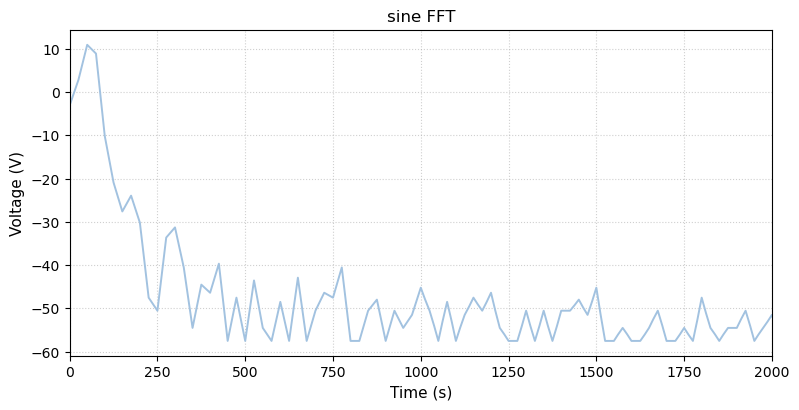

In [206]:
# df = pd.read_csv('sin_FFT.CSV', skiprows=15)
df = pd.read_csv('sine_18V_FFT_new.CSV', skiprows=15)
df.head()

plt.figure(figsize=(8,4))
plt.plot(df['FFT-FREQ'], df['FFT-AMPL'], color='#A2C2E0', linewidth=1.4)
plt.xlabel('Time (s)', fontsize=11)
plt.ylabel('Voltage (V)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.xlim(0,2000)
plt.title('sine FFT')
plt.show()

# plan for analysis

1. square wave stage
- include time-domain plot
- note amplitude, period, and rise/fall times
- optional: show FFT to verify odd harmonics

Record: 
- csv waveform
- amplitude
- period/frequency
- optional:
    - duty cycle (50% for perfect square wave)
    - FFT should show strong odd harmonics
    - rise/fall time

$$ \text{Duty cycle} = \frac{\text{time signal is high}}{\text{total period}}\times 100\%$$

2. triangle wave stage
- show time-domain plot
- point out linear ramps and symmetry
- optional: show FFT to show falloff in harmonics

Record:
- csv waveform
- amplitude (p2p or RMS)
- frequency/period
- linearity of rising/falling slopes
- symmetry (positive and negative lobes should be equal)

3. sine wave stage
- time-domain plot
- RMS sine fit
- FFT and THD
- detailed discussion of distortion discussion

sample discussion: 

The square wave output was verified to have a 50% duty cycle and a frequency of approximately 298 Hz, matching the function generator design. The triangle wave, generated via integration, exhibited linear rising and falling edges with a similar frequency and symmetric amplitude. No additional distortion analysis was performed for these stages, as their harmonic content is inherent to their waveform shape.

The triangle wave output had a peak-to-peak voltage of approximately [e.g. 4.00 V] and a frequency of [e.g. 297.8 Hz], matching the square wave input. Visual inspection confirmed that the rising and falling edges were linear and symmetric, consistent with ideal triangle wave behavior. No distortion analysis was performed since harmonic content is inherent in triangle waves.